In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM,Bidirectional,GRU
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.utils import to_categorical
import datetime
import io
import itertools
# import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import sys
import os
# Obtener la ruta del directorio actual
os.chdir('..')
current_dir = os.getcwd()
print(current_dir)

# Construir la ruta relativa al directorio que quieres agregar
relative_dir = os.path.join(current_dir, 'mis_pkgs/')

# Agregar la ruta relativa al sys.path
sys.path.insert(0, relative_dir)

from MIOPATIA_db import DB_management as db 
np.log2(10)

2024-09-18 10:28:42.539163: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-18 10:28:42.539368: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-18 10:28:42.559515: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-18 10:28:42.635526: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-18 10:28:43.866058: W tensorflow/compiler/tf2

/home/rgadea/nuevas_investigaciones_alimentos_2024


3.321928094887362

In [2]:
numero_muestras=150
numero_clases=2
entrada=[3,4]
numero_entradas = 2
numero_epochs=20000

Voy a quedarme con los 50 atunes P1 para obtener conjunto de training y validacion

In [3]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Add, Activation, Concatenate, Conv2D, Dropout 
from tensorflow.keras.layers import Flatten, Input, GlobalAveragePooling2D, MaxPooling2D
import tensorflow.keras.backend as K

__version__ = '0.0.1'


def SqueezeNet(input_shape, nb_classes, use_bypass=False, dropout_rate=None, compression=1.0):
    """
    Creating a SqueezeNet of version 1.0
    
    Arguments:
        input_shape  : shape of the input images e.g. (224,224,3)
        nb_classes   : number of classes
        use_bypass   : if true, bypass connections will be created at fire module 3, 5, 7, and 9 (default: False)
        dropout_rate : defines the dropout rate that is accomplished after last fire module (default: None)
        compression  : reduce the number of feature-maps (default: 1.0)
        
    Returns:
        Model        : Keras model instance
    """
    
    input_img = Input(shape=input_shape)

    x = Conv2D(int(96*compression), (7,7), activation='relu', strides=(2,2), padding='same', name='conv1')(input_img)

    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool1')(x)
    
    x = create_fire_module(x, int(16*compression), name='fire2')
    x = create_fire_module(x, int(16*compression), name='fire3', use_bypass=use_bypass)
    x = create_fire_module(x, int(32*compression), name='fire4')
    
    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool4')(x)
    
    x = create_fire_module(x, int(32*compression), name='fire5', use_bypass=use_bypass)
    x = create_fire_module(x, int(48*compression), name='fire6')
    x = create_fire_module(x, int(48*compression), name='fire7', use_bypass=use_bypass)
    x = create_fire_module(x, int(64*compression), name='fire8')
    
    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool8')(x)
    
    x = create_fire_module(x, int(64*compression), name='fire9', use_bypass=use_bypass)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)
        
    x = output(x, nb_classes)

    return Model(inputs=input_img, outputs=x)


def SqueezeNet_11(input_shape, nb_classes, dropout_rate=None, compression=1.0):
    """
    Creating a SqueezeNet of version 1.1
    
    2.4x less computation over SqueezeNet 1.0 implemented above.
    
    Arguments:
        input_shape  : shape of the input images e.g. (224,224,3)
        nb_classes   : number of classes
        dropout_rate : defines the dropout rate that is accomplished after last fire module (default: None)
        compression  : reduce the number of feature-maps
        
    Returns:
        Model        : Keras model instance
    """
    
    input_img = Input(shape=input_shape)

    x = Conv2D(int(64*compression), (3,3), activation='relu', strides=(2,2), padding='same', name='conv1')(input_img)

    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool1')(x)
    
    x = create_fire_module(x, int(16*compression), name='fire2')
    x = create_fire_module(x, int(16*compression), name='fire3')
    
    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool3')(x)
    
    x = create_fire_module(x, int(32*compression), name='fire4')
    x = create_fire_module(x, int(32*compression), name='fire5')
    
    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool5')(x)
    
    x = create_fire_module(x, int(48*compression), name='fire6')
    x = create_fire_module(x, int(48*compression), name='fire7')
    x = create_fire_module(x, int(64*compression), name='fire8')
    x = create_fire_module(x, int(64*compression), name='fire9')

    if dropout_rate:
        x = Dropout(dropout_rate)(x)
    
    # Creating last conv10
    x = output(x, nb_classes)

    return Model(inputs=input_img, outputs=x)


def output(x, nb_classes):
    x = Conv2D(nb_classes, (1,1), strides=(1,1), padding='valid', name='conv10')(x)
    x = GlobalAveragePooling2D(name='avgpool10')(x)
    x = Activation("softmax", name='softmax')(x)
    return x


def create_fire_module(x, nb_squeeze_filter, name, use_bypass=False):
    """
    Creates a fire module
    
    Arguments:
        x                 : input
        nb_squeeze_filter : number of filters of squeeze. The filtersize of expand is 4 times of squeeze
        use_bypass        : if True then a bypass will be added
        name              : name of module e.g. fire123
    
    Returns:
        x                 : returns a fire module
    """
    
    nb_expand_filter = 4 * nb_squeeze_filter
    squeeze    = Conv2D(nb_squeeze_filter,(1,1), activation='relu', padding='same', name='%s_squeeze'%name)(x)
    expand_1x1 = Conv2D(nb_expand_filter, (1,1), activation='relu', padding='same', name='%s_expand_1x1'%name)(squeeze)
    expand_3x3 = Conv2D(nb_expand_filter, (3,3), activation='relu', padding='same', name='%s_expand_3x3'%name)(squeeze)
    
    axis = get_axis()
    x_ret = Concatenate(axis=axis, name='%s_concatenate'%name)([expand_1x1, expand_3x3])
    
    if use_bypass:
        x_ret = Add(name='%s_concatenate_bypass'%name)([x_ret, x])
        
    return x_ret


def get_axis():
    axis = -1 if K.image_data_format() == 'channels_last' else 1
    return axis


[[11.9553903   0.11806244]
 [11.95209799  0.12106068]
 [11.94656882  0.13020616]
 [11.94416308  0.13781044]
 [11.93693828  0.14153649]
 [11.93138039  0.14688544]
 [11.92070827  0.15322622]
 [11.91654591  0.16116814]
 [11.90931088  0.16995489]
 [11.89665979  0.17716056]
 [11.88703254  0.1855627 ]
 [11.87746009  0.19438772]
 [11.86359223  0.20459215]
 [11.8533375   0.21282748]
 [11.83941614  0.22027395]
 [11.82908385  0.23243594]
 [11.81211495  0.2415678 ]
 [11.78814919  0.25097663]
 [11.77438858  0.25933521]
 [11.75685015  0.26968637]
 [11.73549106  0.27881591]
 [11.71155863  0.28698274]
 [11.68915028  0.29673122]
 [11.66661579  0.30731965]
 [11.64104942  0.31736492]
 [11.61148051  0.32659304]
 [11.58343171  0.33587824]
 [11.5533494   0.34442209]
 [11.52279756  0.35300879]
 [11.49151364  0.36091834]
 [11.45721734  0.36957169]
 [11.4247003   0.37726122]
 [11.38960633  0.38346107]
 [11.35483781  0.39127886]
 [11.31953985  0.39734043]
 [11.2811545   0.40207862]
 [11.24196487  0.40859433]
 

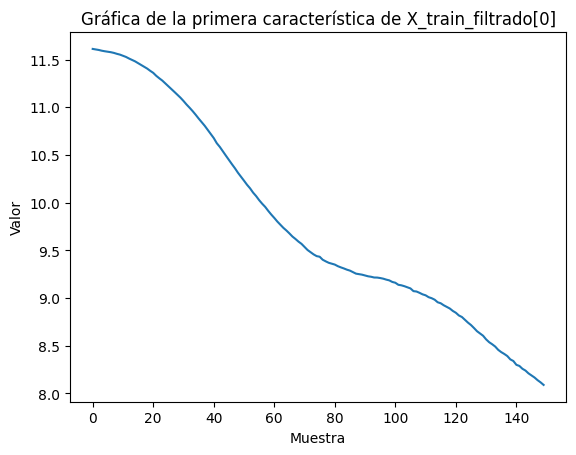

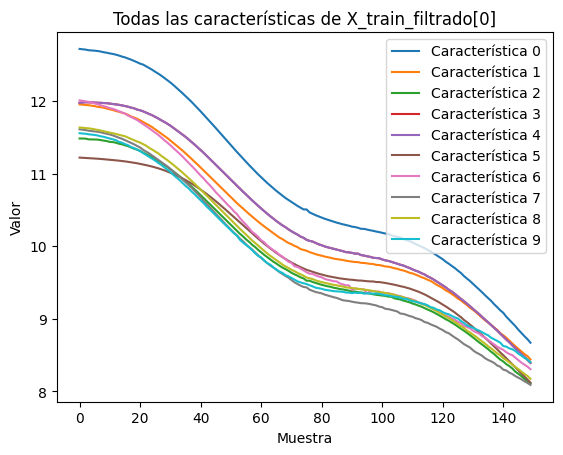

In [4]:
filename = "COPIA_PANDAS/medidas_agilent_2023_y_2024_201_puntos_clasificados.hdf"
with pd.HDFStore(filename,complib="zlib",complevel=4) as hdf_db:
    pre_p_e1  = hdf_db.get('data/pollos_estado')
    pre_p_e1 = pre_p_e1.loc[pre_p_e1['Pollo'] != 0]
    # p_e =pre_p_e1.drop_duplicates(subset = ['Pollo', 'Medida'],  keep = 'last').reset_index(drop = True)
    t    = hdf_db.get('data/tabla')
    X_train=[]

    y_train=[]
    x=0
    for index, row in pre_p_e1.iterrows():   # El primer registro no se toma en cuenta porque es basura
        Primero = int(row['Primero'])
        Ultimo  = int(row['Ultimo'])
        estado  = int(row['Estado'])
        #print(Primero)
        #print(Ultimo)
        #print(estado)
        if estado<6:
            if numero_clases==2:
                if estado == 0 or estado== 1:
                    target = 0
                else:
                    target = 1
            else:
                target=estado
            pepito=np.array(t.iloc[Primero+50:Primero+200])
            X_train.append(pepito[:,entrada])
            y_train.append(target)
            y_train_to_categorical = to_categorical(y_train)
            x=x+1

X_train_filtrado=np.zeros((x,numero_muestras,numero_entradas))
X_train = np.array(X_train)
y_train = np.array(y_train)
X_train_filtrado[:,:,0] =(np.log(X_train[:,:,0])) 
X_train_filtrado[:,:,1]=-X_train[:,:,1]*2*180/(np.pi*256)

#y_train_filtrado = y_train
y_train_filtrado = y_train_to_categorical


scaler = MinMaxScaler(feature_range=(0, 1))
#scaler = StandardScaler()



#data1=np.concatenate((X_train_filtrado,X_test_filtrado1),axis=0) 

data_2d = X_train_filtrado.reshape(-1, X_train_filtrado.shape[-1])
normalized_data_2d = scaler.fit_transform(data_2d)



X_train_Normalizado=normalized_data_2d.reshape(X_train_filtrado.shape)
y_train_Normalizado=y_train_filtrado

print(X_train_filtrado[1])
plt.plot(X_train_filtrado[7][:, 0])
plt.title('Gráfica de la primera característica de X_train_filtrado[0]')
plt.xlabel('Muestra')
plt.ylabel('Valor')
plt.show()

# Si quieres plotear todas las características de X_train_filtrado[0] en la misma gráfica:
for i in range(10):
    plt.plot(X_train_filtrado[i][:, 0], label=f'Característica {i}')
plt.title('Todas las características de X_train_filtrado[0]')
plt.xlabel('Muestra')
plt.ylabel('Valor')
plt.legend()
plt.show()

Vamos a hacer los conjuntos de entrenamiento validacion y test

In [5]:
# Divide el dataset en entrenamiento y temporal (test+validación)
# X_temp, X_test_def, y_temp, y_test_def = train_test_split(X_train_Normalizado, y_train_Normalizado, test_size=0.2, stratify=y_train_Normalizado, random_state=42)

# Divide el dataset temporal en validación y test
X_train_def, X_val_def, y_train_def, y_val_def = train_test_split(X_train_Normalizado, y_train_Normalizado, test_size=0.20, stratify=y_train_Normalizado, random_state=42)

# Ahora, X_train, X_val y X_test contienen los datos de entrada para los conjuntos de entrenamiento, validación y prueba, respectivamente.
# y_train, y_val y y_test contienen las clases correspondientes.

In [6]:
print(X_train_def.shape)
print(X_val_def.shape)

print(y_train_def.shape)
print(y_val_def.shape)


(153, 150, 2)
(39, 150, 2)
(153, 2)
(39, 2)


In [7]:
#%load_ext tensorboard

#%tensorboard --logdir logs
#log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
#tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

In [8]:
def plot_to_image(figure):
    """
    Converts the matplotlib plot specified by 'figure' to a PNG image and
    returns it. The supplied figure is closed and inaccessible after this call.
    """
    
    buf = io.BytesIO()
    
    # Use plt.savefig to save the plot to a PNG in memory.
    plt.savefig(buf, format='png')
    
    # Closing the figure prevents it from being displayed directly inside
    # the notebook.
    plt.close(figure)
    buf.seek(0)
    
    # Use tf.image.decode_png to convert the PNG buffer
    # to a TF image. Make sure you use 4 channels.
    image = tf.image.decode_png(buf.getvalue(), channels=4)
    
    # Use tf.expand_dims to add the batch dimension
    image = tf.expand_dims(image, 0)
    
    return image

In [9]:
def plot_confusion_matrix(cm, class_names):
    """
    Returns a matplotlib figure containing the plotted confusion matrix.
    
    Args:
       cm (array, shape = [n, n]): a confusion matrix of integer classes
       class_names (array, shape = [n]): String names of the integer classes
    """
    
    figure = plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    
    # Normalize the confusion matrix.
    cm = np.around(cm.astype('float') / cm.sum(axis=1)[:, np.newaxis], decimals=2)
    
    # Use white text if squares are dark; otherwise black.
    threshold = cm.max() / 2.
    threshold = 0.5
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        color = "red" if cm[i, j] > threshold else "black"
        plt.text(j, i, cm[i, j], horizontalalignment="center", color=color)
        
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    return figure

In [10]:
factor_aprendizaje=0.001
dimension_LSTM=32
dimension_dense1=160
dimension_dense2=16
algoritmo='rmsprop'
supermax=8*4
lossfunction='categorical_crossentropy'
def create_model():

    model = Sequential()
    model.add(GRU(dimension_LSTM, return_sequences=True,recurrent_regularizer='L1L2',input_shape=(numero_muestras, numero_entradas)))
    model.add(Flatten())  
    #model.add(GRU(50, return_sequences=True))
    #model.add(GRU(50, return_sequences=False, recurrent_regularizer='L2'))
    model.add(Dense(dimension_dense1, activation='tanh', activity_regularizer='L1L2'))
    model.add(Dense(dimension_dense2, activation='tanh', activity_regularizer='L1L2'))
    model.add(Dense(numero_clases, activation='sigmoid'))
    model.compile(loss=lossfunction, optimizer=algoritmo, metrics=['accuracy',
                              tf.keras.metrics.Recall(class_id=0),
                              tf.keras.metrics.Recall(class_id=1) #,
                              #tfa.metrics.F1Score(num_classes=numero_clases,average='macro', threshold=0.5)
                              ])
    model.optimizer.lr=(factor_aprendizaje)
    return model

model=create_model()

2024-09-18 10:28:48.666531: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-09-18 10:28:48.926683: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-09-18 10:28:48.926749: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-09-18 10:28:48.929201: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-09-18 10:28:48.929277: I external/local_xla/xla/stream_executor

In [11]:

experimento="LOMOS_Agilent_5clases_GRU1_{}_dense1_{}_dense2_{}_loss_{}_lr_{}_algoritmo_{}".format(dimension_LSTM,dimension_dense1,dimension_dense2,lossfunction,factor_aprendizaje,algoritmo)
logdir="./logs/defs_septiembre/{}_{}".format(experimento,datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback=tf.keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=1)
# file_writer_cm = tf.summary.create_file_writer(logdir + '/cm')


In [12]:
if numero_clases==2:
    class_names=['Buenos', 'Malos']
else:
    class_names=['A', 'B+', 'B', 'B-','C']

In [13]:
def log_confusion_matrix(epoch, logs):
    
    # Use the model to predict the values from the test_images.
    y_pred = model.predict(X_test_def)
    #y_pred1=y_pred[:,-1]
    y_pred2=y_pred.argmax(axis=1)
    #y_pred2=np.where(y_pred>0,1,0)
    #y_pred2=y_pred2[:,-1]
    if numero_clases==2:
        classes = [0, 1]    
    else:

        classes = [0, 1, 2, 3, 4] 
    #classes = [0, 1]
    y_test_def2=np.argmax(y_test_def,axis=1)  
    #y_test_def2=np.where(y_test_def>0,1,0)
    cm=confusion_matrix(y_test_def2, y_pred2,labels=classes)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    figura = plot_confusion_matrix(cm, class_names=class_names)
    cm_image = plot_to_image(figura)
    
    # Log the confusion matrix as an image summary.
    with file_writer_cm.as_default():
        tf.summary.image("Confusion Matrix", cm_image, step=epoch)

In [14]:
cm_callback = tf.keras.callbacks.LambdaCallback(on_epoch_end=log_confusion_matrix)
print(y_train_Normalizado.shape)
print(y_val_def.shape)

(192, 2)
(39, 2)


In [15]:
# Crear un callback para guardar los mejores pesos
#checkpoint = tf.keras.callbacks.ModelCheckpoint('best_weights.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')


In [16]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.95,
    patience=1000,
    min_lr=0.0001
)
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0, patience=2000, verbose=2, mode='auto', baseline=None, restore_best_weights=True)
model.fit(X_train_def, y_train_def, epochs=numero_epochs, batch_size=20, callbacks=[tensorboard_callback,lr_callback,early_stop], validation_data=(X_val_def, y_val_def))
# Final evaluation of the model 
scores = model.evaluate(X_val_def, y_val_def, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Epoch 1/20000


2024-09-18 10:28:59.984677: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-09-18 10:29:00.136091: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f54c40aec00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-09-18 10:29:00.136134: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1070 Ti, Compute Capability 6.1
2024-09-18 10:29:00.170243: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1726648140.258539 1058876 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 [==============================] - 3s 128ms/step - loss: 1.9866 - accuracy: 0.5033 - recall: 0.8353 - recall_1: 0.0882 - val_loss: 0.7739 - val_accuracy: 0.5641 - val_recall: 1.0000 - val_recall_1: 0.0588 - lr: 0.0010
Epoch 2/20000
8/8 [==============================] - 0s 42ms/step - loss: 0.7046 - accuracy: 0.5294 - recall: 1.0000 - recall_1: 0.8824 - val_loss: 0.6890 - val_accuracy: 0.5641 - val_recall: 1.0000 - val_recall_1: 1.0000 - lr: 0.0010
Epoch 3/20000
8/8 [==============================] - 0s 44ms/step - loss: 0.6907 - accuracy: 0.5163 - recall: 1.0000 - recall_1: 1.0000 - val_loss: 0.7055 - val_accuracy: 0.5641 - val_recall: 1.0000 - val_recall_1: 1.0000 - lr: 0.0010
Epoch 4/20000
8/8 [==============================] - 0s 46ms/step - loss: 0.6939 - accuracy: 0.5556 - recall: 1.0000 - recall_1: 1.0000 - val_loss: 0.6826 - val_accuracy: 0.5641 - val_recall: 1.0000 - val_recall_1: 1.0000 - lr: 0.0010
Epoch 5/20000
8/8 [==============================] - 0s 49ms/step - loss:

In [17]:
y_pred = model.predict(X_val_def)
#y_pred1=y_pred[:,-1]
y_pred2=np.argmax(y_pred,axis=1)
#y_pred2=np.where(y_pred>0,1,0)
#y_pred2=y_pred2[:,-1]
y_test_def2=np.argmax(y_val_def,axis=1)
#y_test_def2=np.where(y_test_def>0,1,0)
print(y_pred.shape)
print(y_pred2.shape)
print(y_test_def2.shape)
#print(y_test_def[25])
print(y_val_def)
print(y_pred)

2/2 [==============================] - 0s 16ms/step
(39, 2)
(39,)
(39,)
[[1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]]
[[0.8876323  0.56685245]
 [0.45861793 0.5535504 ]
 [0.5355837  0.5763769 ]
 [0.318326   0.582012  ]
 [0.6198874  0.507403  ]
 [0.38107705 0.65089625]
 [0.38067818 0.80346763]
 [0.5954419  0.5815334 ]
 [0.6579816  0.4452191 ]
 [0.5983624  0.5445936 ]
 [0.62613946 0.47494414]
 [0.38635984 0.38806972]
 [0.80887085 0.33973545]
 [0.55673754 0.49880227]
 [0.34002638 0.8264705 ]
 [0.4845955  0.638937  ]
 [0.60656685 0.55567914]
 [0.59072757 0.56509966]
 [0.33415386 0.5014696 ]
 [0.4825564  0.61846006]
 [0.54022896 0.5661131 ]
 [0.52824455 0.5034861 ]
 [0.64196527 0.47503784]
 

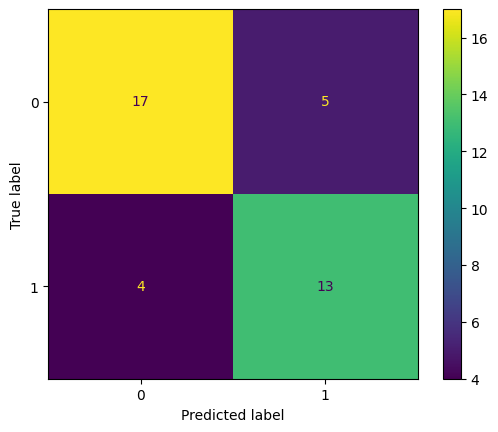

In [18]:
#docs_infra: no_execute
if numero_clases==2:
    classes = [0, 1]
else:   
    classes = [0, 1, 2, 3, 4]
#classes = [0, 1]
cm=confusion_matrix(y_test_def2, y_pred2,labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [19]:
from sklearn.metrics import classification_report
if numero_clases==2:
    target_names = ['Buenos', 'Malos']
else:   
    target_names = ['A', 'B+', 'B', 'B-','C']
print(classification_report(y_test_def2, y_pred2, target_names=target_names, digits=4))

              precision    recall  f1-score   support

      Buenos     0.8095    0.7727    0.7907        22
       Malos     0.7222    0.7647    0.7429        17

    accuracy                         0.7692        39
   macro avg     0.7659    0.7687    0.7668        39
weighted avg     0.7715    0.7692    0.7698        39



In [20]:
# model.save('modelos/modelote1203_200')  # creates a HDF5 file 'my_model.h5'

In [21]:
#model.save('idea.h5')  # creates a HDF5 file 'my_model.h5'
model.save('modelos/modelo_perfecto_{}_{}.h5'.format(experimento,datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))) 

/home/rgadea/.local/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [22]:
#este modo de guardar no funciona en esta version de tensorflow
model.save('modelos/modelo_perfecto_para_matlab_prueba') 

INFO:tensorflow:Assets written to: modelos/modelo_perfecto_para_matlab_prueba/assets


INFO:tensorflow:Assets written to: modelos/modelo_perfecto_para_matlab_prueba/assets


In [23]:
import scipy.io as sio

In [24]:
savedict={'X_val_def':X_val_def,'y_val_def':y_val_def}

sio.savemat('Train_Normalizado_ver4_8.mat',savedict)

In [25]:
#salida=model.predict(X_test_def)    
inputs=model.layers[0].input
# Asume que model es tu modelo original y que quieres la salida de la primera capa
output_layer = model.layers[0].output

# Crea un nuevo modelo que tenga la misma entrada que el modelo original, pero cuya salida sea la salida de la capa que te interesa
intermediate_model = tf.keras.Model(inputs=inputs, outputs=output_layer)

#este modo de guardar no funciona en esta version de tensorflow
intermediate_model.save('modelos/modelo_perfecto_para_matlab_septiembre_2024_modulo_fase_solo_gru_normalizado_leave_k_out') 

INFO:tensorflow:Assets written to: modelos/modelo_perfecto_para_matlab_septiembre_2024_modulo_fase_solo_gru_normalizado_leave_k_out/assets


INFO:tensorflow:Assets written to: modelos/modelo_perfecto_para_matlab_septiembre_2024_modulo_fase_solo_gru_normalizado_leave_k_out/assets


In [26]:
savedict={'X_train_filtrado':X_val_def,'y_train_filtrado':y_val_def}

sio.savemat('Train_Normalizado_version_septiembre_normalizado_leave_k_out.mat',savedict)

In [27]:
from sklearn.model_selection import train_test_split

from sklearn.model_selection import KFold
from sklearn.metrics import classification_report,recall_score

In [28]:
inputs=X_train_Normalizado.reshape(X_train_Normalizado.shape[0],-1)
targets=y_train_Normalizado

In [29]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.95,
    patience=1000,
    min_lr=0.0001
)
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0, patience=2000, verbose=2, mode='auto', baseline=None, restore_best_weights=True)
# Define the K-fold Cross Validator
kfold = KFold(n_splits=10, shuffle=True)
# Define per-fold score containers
acc_per_fold = []
loss_per_fold = []
sensibilidad_YAKE_per_fold=[]
sensibilidad_no_YAKE_per_fold=[]
# K-fold Cross Validation model evaluation
fold_no = 1
for train, test in kfold.split(inputs, targets):
    model=create_model()
     # Generate a print
    print('------------------------------------------------------------------------')
    print(f'Training for fold {fold_no} ...')
    inputs_good=inputs.reshape(X_train_filtrado.shape)
    # Fit data to model
    history = model.fit(inputs_good[train], targets[train],
              batch_size=20,
              epochs=numero_epochs,
              callbacks=[early_stop,lr_callback, tensorboard_callback],
              validation_data=(inputs_good[test],targets[test])
              )
    if numero_clases==2:
        target_names = ['Buenos', 'Malos']
    else:   
        target_names = ['A', 'B+', 'B', 'B-','C']
    y_pred = model.predict(inputs_good[test])
    y_pred2=np.argmax(y_pred,axis=1)
    y_test_def2=np.argmax(targets[test],axis=1)
    print(classification_report(y_test_def2, y_pred2, target_names=target_names, digits=4))
    scores2=recall_score(y_test_def2, y_pred2, average=None)
    # Generate generalization metrics
    scores = model.evaluate(inputs_good[test], targets[test], verbose=0)
    print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
    print(scores[2])
    print(scores[3])
    print(scores2[0])
    print(scores2[1])
   # print(scores[4])
    acc_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])
    sensibilidad_no_YAKE_per_fold.append(scores2[0] * 100)
    sensibilidad_YAKE_per_fold.append(scores2[1] * 100)
    # Increase fold number
    fold_no = fold_no + 1

------------------------------------------------------------------------
Training for fold 1 ...
Epoch 1/20000
9/9 [==============================] - 2s 86ms/step - loss: 1.7121 - accuracy: 0.5233 - recall_2: 0.7789 - recall_3: 0.0649 - val_loss: 0.7046 - val_accuracy: 0.6000 - val_recall_2: 1.0000 - val_recall_3: 0.0000e+00 - lr: 0.0010
Epoch 2/20000
9/9 [==============================] - 0s 40ms/step - loss: 0.7400 - accuracy: 0.5407 - recall_2: 0.8737 - recall_3: 0.4416 - val_loss: 0.6844 - val_accuracy: 0.6000 - val_recall_2: 1.0000 - val_recall_3: 0.0000e+00 - lr: 0.0010
Epoch 3/20000
9/9 [==============================] - 0s 40ms/step - loss: 0.7476 - accuracy: 0.4767 - recall_2: 1.0000 - recall_3: 0.4026 - val_loss: 0.6848 - val_accuracy: 0.6000 - val_recall_2: 1.0000 - val_recall_3: 0.0000e+00 - lr: 0.0010
Epoch 4/20000
9/9 [==============================] - 0s 38ms/step - loss: 0.7606 - accuracy: 0.4826 - recall_2: 0.9895 - recall_3: 0.1818 - val_loss: 0.6836 - val_accuracy: 0

1/1 [==============================] - 0s 346ms/step
              precision    recall  f1-score   support

      Buenos     0.7500    0.7500    0.7500         8
       Malos     0.8182    0.8182    0.8182        11

    accuracy                         0.7895        19
   macro avg     0.7841    0.7841    0.7841        19
weighted avg     0.7895    0.7895    0.7895        19

Score for fold 4: loss of 1.5241315364837646; accuracy of 78.94737124443054%
0.75
0.8181818127632141
0.75
0.8181818181818182
------------------------------------------------------------------------
Training for fold 5 ...
Epoch 1/20000
9/9 [==============================] - 4s 103ms/step - loss: 1.7962 - accuracy: 0.5029 - recall_10: 0.4742 - recall_11: 0.0658 - val_loss: 0.9743 - val_accuracy: 0.5263 - val_recall_10: 0.0000e+00 - val_recall_11: 0.0000e+00 - lr: 0.0010
Epoch 2/20000
9/9 [==============================] - 0s 43ms/step - loss: 0.7456 - accuracy: 0.5607 - recall_10: 0.0000e+00 - recall_11: 0.0000e+0

1/1 [==============================] - 0s 264ms/step
              precision    recall  f1-score   support

      Buenos     0.7143    1.0000    0.8333        10
       Malos     1.0000    0.5556    0.7143         9

    accuracy                         0.7895        19
   macro avg     0.8571    0.7778    0.7738        19
weighted avg     0.8496    0.7895    0.7769        19

Score for fold 5: loss of 1.0536730289459229; accuracy of 78.94737124443054%
0.6000000238418579
0.2222222238779068
1.0
0.5555555555555556
------------------------------------------------------------------------
Training for fold 6 ...
Epoch 1/20000
9/9 [==============================] - 2s 99ms/step - loss: 1.5771 - accuracy: 0.5260 - recall_12: 0.8586 - recall_13: 0.1486 - val_loss: 0.7576 - val_accuracy: 0.4211 - val_recall_12: 1.0000 - val_recall_13: 1.0000 - lr: 0.0010
Epoch 2/20000
9/9 [==============================] - 0s 46ms/step - loss: 0.6847 - accuracy: 0.5723 - recall_12: 1.0000 - recall_13: 1.0000 - 

In [30]:
# == Provide average scores ==
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(acc_per_fold)):
  print('------------------------------------------------------------------------')
  print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {acc_per_fold[i]}%')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold)} (+- {np.std(acc_per_fold)})')
print(f'> Loss: {np.mean(loss_per_fold)}')
print('------------------------------------------------------------------------')

------------------------------------------------------------------------
Score per fold
------------------------------------------------------------------------
> Fold 1 - Loss: 0.5889643430709839 - Accuracy: 80.0000011920929%
------------------------------------------------------------------------
> Fold 2 - Loss: 0.6377066373825073 - Accuracy: 85.00000238418579%
------------------------------------------------------------------------
> Fold 3 - Loss: 0.692837119102478 - Accuracy: 73.68420958518982%
------------------------------------------------------------------------
> Fold 4 - Loss: 1.5241315364837646 - Accuracy: 78.94737124443054%
------------------------------------------------------------------------
> Fold 5 - Loss: 1.0536730289459229 - Accuracy: 78.94737124443054%
------------------------------------------------------------------------
> Fold 6 - Loss: 0.8277090191841125 - Accuracy: 73.68420958518982%
------------------------------------------------------------------------
>

In [31]:
# == Provide average scores ==
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(sensibilidad_YAKE_per_fold)):
  print('------------------------------------------------------------------------')
  print(f'> Fold {i+1} - Sensibilidad YAKE: {sensibilidad_YAKE_per_fold[i]} - Sensibilidad NOYAKE: {sensibilidad_no_YAKE_per_fold[i]}%')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Sensibilidad YAKE: {np.mean(sensibilidad_YAKE_per_fold)} (+- {np.std(sensibilidad_YAKE_per_fold)})')
print(f'> Sensibilidad NOYAKE: {np.mean(sensibilidad_no_YAKE_per_fold)} (+- {np.std(sensibilidad_no_YAKE_per_fold)})')
print('------------------------------------------------------------------------')

------------------------------------------------------------------------
Score per fold
------------------------------------------------------------------------
> Fold 1 - Sensibilidad YAKE: 62.5 - Sensibilidad NOYAKE: 91.66666666666666%
------------------------------------------------------------------------
> Fold 2 - Sensibilidad YAKE: 40.0 - Sensibilidad NOYAKE: 100.0%
------------------------------------------------------------------------
> Fold 3 - Sensibilidad YAKE: 66.66666666666666 - Sensibilidad NOYAKE: 85.71428571428571%
------------------------------------------------------------------------
> Fold 4 - Sensibilidad YAKE: 81.81818181818183 - Sensibilidad NOYAKE: 75.0%
------------------------------------------------------------------------
> Fold 5 - Sensibilidad YAKE: 55.55555555555556 - Sensibilidad NOYAKE: 100.0%
------------------------------------------------------------------------
> Fold 6 - Sensibilidad YAKE: 72.72727272727273 - Sensibilidad NOYAKE: 75.0%
----------